# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells within the same brain section;
- Niche: all neighboring cells within the same brain section;
- Niche: cross brain section k-hop neighbouring cells;
- Positive pairs: samples from the same brain section and visualization by prob.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## Gene Expressions

In [2]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
target_sample_ids = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
                  'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
                  'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
db = Database(target_sample_ids)
db.construct(adata_path=[data_folder + 'Zhuang-ABCA-1-raw.h5ad'],
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name='gene_expression',
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

D:\Beaver\code\NicheQueryBenchmark\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading adata...
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Constructing parcellation tree...
INFO:src.NicheQueryPrototype.database:Constructing database for niche query...
INFO:src.NicheQueryPrototype.database:	10000 cells loaded...
INFO:src.NicheQueryPrototype.database:	20000 cells loaded...
INFO:src.NicheQueryPrototype.database:	30000 cells loaded...
INFO:src.NicheQueryPrototype.database:	40000 cells loaded...
INFO:src.NicheQueryPrototype.database:	50000 cells loaded...
INFO:src.NicheQueryPrototype.database:	60000 cells loaded...
INFO:src.NicheQueryPrototype.database:	70000 cells loaded...
INFO:src.NicheQueryPrototype.database:	8

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.086 slice.
D:\Beaver\code\NicheQueryBenchmark\src\NicheQueryPrototype\niche.py:143: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


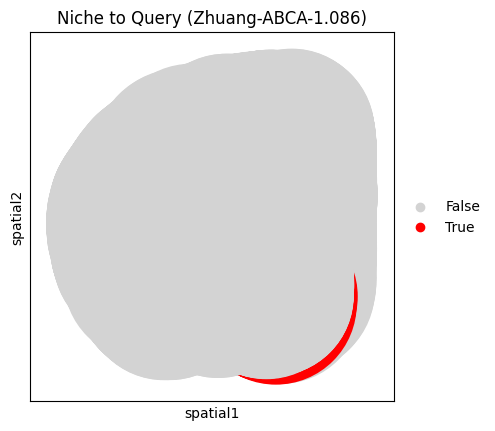

D:\Beaver\code\NicheQueryBenchmark\src\NicheQueryPrototype\niche.py:149: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


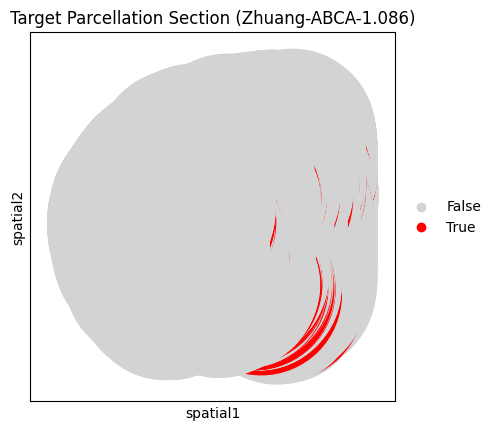

In [3]:
# step 2: construct niche to query

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='44271692540130311954709901940577285312', sample_id='Zhuang-ABCA-1.086', k=10, cell_limit=100,
                                  parcellation_index=987)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

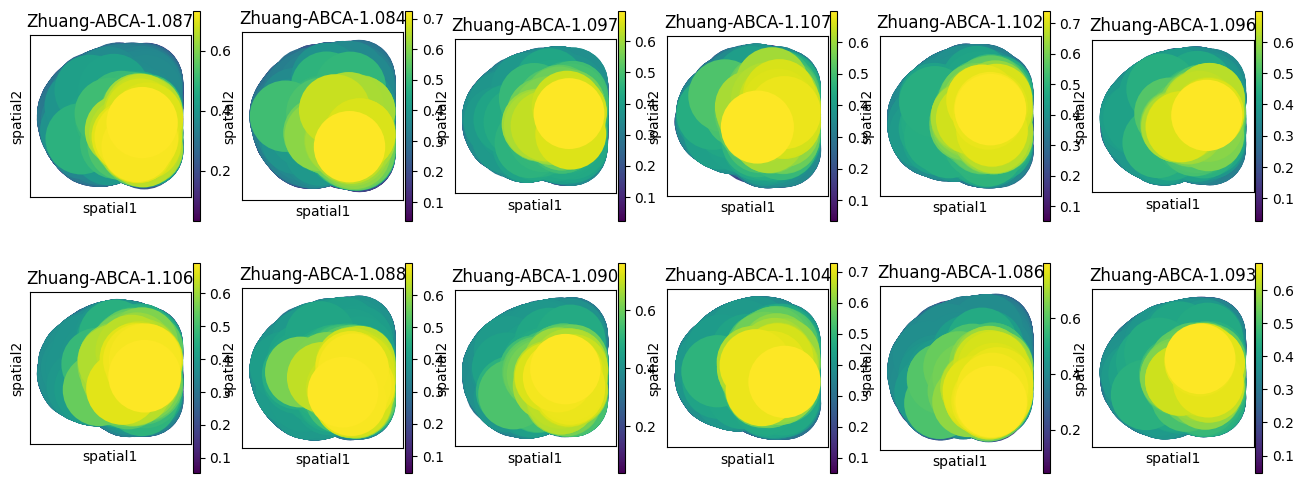

In [4]:
# step 3: run niche query on given samples
niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples)

In [10]:
# step 4: classification report
from typing import List, Tuple

import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch_cluster import knn_graph

from src.NicheQueryPrototype.database import Database, Sample
import scanpy as sc
from src.NicheQueryPrototype.niche import Niche, logger


class NicheQuery:
    def __init__(self, db: Database, niche: Niche, k: int):
        assert 0 < k <= 10, "Invalid subgraph parameter, should be between 1 and 10 (included)"
        self.db = db
        self.niche = niche
        self.k = k

    @staticmethod
    def get_parcellation_mask(sample: Sample, parcellation_index: int) -> np.ndarray:
        parcellation_indices = np.array([c.parcellation_index for c in sample.cells])
        return (parcellation_indices == parcellation_index).astype(int)

    """
    Generate niche embedding and parcellation mask for all samples.
    """

    def generate_niche_features_and_parcellation_mask(self, samples: List[Sample], overwrite=False):
        def _row_normalized_adjacency(edge_index: torch.Tensor, num_nodes: int, device):
            """
            edge_index: [2, E], where edge_index[0] = source(row), edge_index[1] = target(col)
            Returns sparse COO tensor A_norm of shape [N, N] with row-normalized weights.
            """
            row = edge_index[0]
            col = edge_index[1]
            val = torch.ones(row.numel(), device=device, dtype=torch.float32)

            # Row degree: deg[i] = number of outgoing edges from i
            deg = torch.bincount(row, minlength=num_nodes).to(torch.float32)
            deg_inv = 1.0 / torch.clamp(deg, min=1.0)

            # Row-normalize: each edge from row i gets weight 1/deg[i]
            val = val * deg_inv[row]

            A_norm = torch.sparse_coo_tensor(
                indices=torch.stack([row, col], dim=0),
                values=val,
                size=(num_nodes, num_nodes),
                device=device,
            ).coalesce()

            return A_norm

        for sample in samples:
            logger.info(f"[START] start computing niche features for sample {sample.id}")
            if not overwrite and sample.niche_features is not None and sample.target_parcellation_mask is not None:
                logger.info(f"[SKIP] finish sample: {sample.id}")
                continue

            # (1) features -> torch tensor (N, F)
            X_np = np.asarray([np.asarray(c.feature).squeeze() for c in sample.cells], dtype=np.float32)
            if X_np.ndim != 2:
                X_np = X_np.reshape(X_np.shape[0], -1)

            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            X = torch.from_numpy(X_np).to(device=device, dtype=torch.float32)

            # (2) parcellation mask
            sample.target_parcellation_mask = self.get_parcellation_mask(sample, self.niche.parcellation_index)

            # (3) KNN graph in feature space
            edge_index = knn_graph(X, k=self.k, loop=True)  # shape [2, E]

            # (4) A_norm @ X  (row-normalized adjacency)
            N = X.size(0)
            A_norm = _row_normalized_adjacency(edge_index, num_nodes=N, device=device)
            niche_X = torch.sparse.mm(A_norm, X)  # (N, F)
            sample.niche_features = niche_X.detach().cpu().numpy()

            logger.info(f"[DONE] finish sample: {sample.id}")

    """
    Perform niche query task on a sample and return cosine similarity between query niche and each niches.
    """

    def niche_query_within_a_sample(self, sample: Sample) -> np.ndarray:
        cos_sim = cosine_similarity(self.niche.feature.reshape(1, -1), sample.niche_features).squeeze()
        for i, cell in enumerate(sample.cells):
            cell.similarity = cos_sim[i]
        return cos_sim

    """
    Get the best threshold and compute F1 scores for niche matching.
    """

    def get_best_threshold(self, samples: List[Sample]) -> Tuple[float, float]:
        cos_sim_list = []
        parcellation_mask_list = []
        for sample in samples:
            cos_sim_list.append(self.niche_query_within_a_sample(sample))
            parcellation_mask_list.append(sample.target_parcellation_mask)

        cos_sim = np.concatenate([np.asarray(x).reshape(-1) for x in cos_sim_list]).astype(np.float32)
        parcellation_mask = np.concatenate([np.asarray(x).reshape(-1) for x in parcellation_mask_list])
        parcellation_mask = (parcellation_mask > 0).astype(np.int32)

        precision, recall, thresholds = precision_recall_curve(y_true=parcellation_mask, y_score=cos_sim,
                                                               pos_label=1)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        best_idx = np.argmax(f1)
        best_threshold = thresholds[best_idx]
        best_f1 = f1[best_idx]
        logger.info(f"Best threshold found on {len(samples)} samples: {best_threshold}")
        logger.info(f"Maximized F1 score: {best_f1}")
        return best_threshold, best_f1

    """
    Perform niche query task and return samples with pred niches.
    """

    def niche_query_with_classification_report(self, best_threshold: float, samples: List[Sample]) -> List[Sample]:
        cos_sim_list = []
        parcellation_mask_list = []
        for sample in samples:
            cos_sim_list.append(self.niche_query_within_a_sample(sample))
            if sample.target_parcellation_mask is not None:
                parcellation_mask_list.append(sample.target_parcellation_mask)

        cos_sim = np.concatenate([np.asarray(x).reshape(-1) for x in cos_sim_list]).astype(np.float32)
        pred = cos_sim > best_threshold
        parcellation_mask = np.concatenate([np.asarray(x).reshape(-1) for x in parcellation_mask_list])
        parcellation_mask = (parcellation_mask > 0).astype(np.int32)
        logger.info(f"Classification report with {len(samples)} samples:")
        logger.info(f'\n{classification_report(y_true=parcellation_mask, y_pred=pred, target_names=["Others", "Target Parcellation"])}\n')

        return [samples[i] for i, cos_sim in enumerate(cos_sim_list) if cos_sim.any() > best_threshold]

    """
    Perform niche query task, find best threshold and generate classification report.
    step 1: compute the best threshold with 30% samples with the parcellation section
    step 2: use the best threshold to run niche query
    step 3: compute f1 score using all samples
    """

    def niche_query_verification(self, search_samples: List[Sample]):
        self.generate_niche_features_and_parcellation_mask(search_samples)
        target_samples_ = [s for s in search_samples if s.target_parcellation_mask.sum() > 0]
        non_target_samples = [s for s in search_samples if s.target_parcellation_mask.sum() == 0]
        val_samples, test_samples = train_test_split(
            target_samples_,
            test_size=0.7,
            random_state=42,
            shuffle=True
        )
        best_threshold, _ = self.get_best_threshold(val_samples)

        all_test_samples = list(test_samples) + list(non_target_samples)
        np.random.shuffle(all_test_samples)
        self.niche_query_with_classification_report(best_threshold, all_test_samples)

    """
    Perform a niche query task and visualize results using cosine similarity on given samples.
    """

    def niche_query_visualization(self, search_samples: List[Sample]) -> None:
        self.generate_niche_features_and_parcellation_mask(search_samples)
        for sample in search_samples:
            self.niche_query_within_a_sample(sample)
            if 'niche_query_result' not in sample.adata.obs:
                sample.adata.obs['niche_query_result'] = np.nan
            for cell in sample.cells:
                sample.adata.obs.loc[cell.id, 'niche_query_result'] = float(cell.similarity)

        fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
        axes = axes.flatten()
        for i, sample in enumerate(search_samples):
            sc.pl.spatial(sample.adata, color='niche_query_result', ax=axes[i], show=False, spot_size=5,
                          title=f"{sample.id}")

niche_query_1 = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query_1.niche_query_verification(search_samples=query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr